# 08 — Batching Ablation

Compares three batching strategies against the `both_attention` baseline.
All four runs use the full feature set (surface normals + curvature + multi-agg).

| Suffix | Strategy |
|---|---|
| `both` | Standard batching — baseline |
| `inv_size` | Protein-weighted MSE (equal weight per protein, not per vertex) |
| `grad_accum` | Gradient accumulation — 2 steps |
| `both_batching` | Protein-weighted + grad accumulation combined |

**Sections:**
1. Configuration
2. Metrics comparison
3. Training noise analysis
4. Error distributions

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid."""
    available = [r for r in runs if (r["plot_dir"] / filename).exists()]
    if not available:
        print(f"No '{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(run["plot_dir"] / filename))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_batching_bars(df, title):
    """Single-panel grouped bar chart for batching ablation runs."""
    if df.empty:
        print("No data to plot.")
        return
    metrics = [("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")]
    n_metrics   = len(metrics)
    total_width = 0.7
    bar_w       = total_width / n_metrics
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    x = range(len(df))
    for i, (metric, color) in enumerate(metrics):
        if metric not in df.columns or df[metric].isna().all():
            continue
        offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
        bars = ax.bar(offsets, df[metric], width=bar_w, color=color, label=metric, zorder=3)
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
    ax.set_xlabel("Batching strategy")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["Suffix"].tolist(), fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [3]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

BATCHING_RUNS = [
    dict(label="both (baseline)", suffix="both",
         plot_dir=EVAL_ROOT/"attention_both",         ckpt_dir=CKPT_ROOT/"attention_both"),
    dict(label="inv_size",         suffix="inv_size",
         plot_dir=EVAL_ROOT/"attention_inv_size",     ckpt_dir=CKPT_ROOT/"attention_inv_size"),
    dict(label="grad_accum",       suffix="grad_accum",
         plot_dir=EVAL_ROOT/"attention_grad_accum",   ckpt_dir=CKPT_ROOT/"attention_grad_accum"),
    dict(label="both_batching",    suffix="both_batching",
         plot_dir=EVAL_ROOT/"attention_both_batching", ckpt_dir=CKPT_ROOT/"attention_both_batching"),
]

print(f"{'Run':<22}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 42)
for r in BATCHING_RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<22}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                      Plots   Metrics
------------------------------------------
both (baseline)            yes       yes
inv_size                   yes       yes
grad_accum                 yes       yes
both_batching              yes       yes


## 2. Metrics Comparison

In [4]:
rows_bat = []
for run in BATCHING_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_bat.append({
        "Run":            run["label"],
        "Suffix":         run["suffix"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Val loss":       g.get("loss"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

df_bat = pd.DataFrame(rows_bat)
pd.set_option("display.float_format", "{:.4f}".format)
display(df_bat)

,Run,Suffix,Pearson r,RMSE,MAE,Val loss,Train time (s),N proteins
0,both (baseline),both,0.7655,2.9789,2.2636,0.3726,1374.2000,20
1,inv_size,inv_size,0.7756,2.9154,2.2095,0.3496,1782.9000,20
2,grad_accum,grad_accum,0.7534,3.0010,2.2839,0.3793,1721.7000,20
3,both_batching,both_batching,0.7831,2.9417,2.2233,0.3575,2004.3000,20


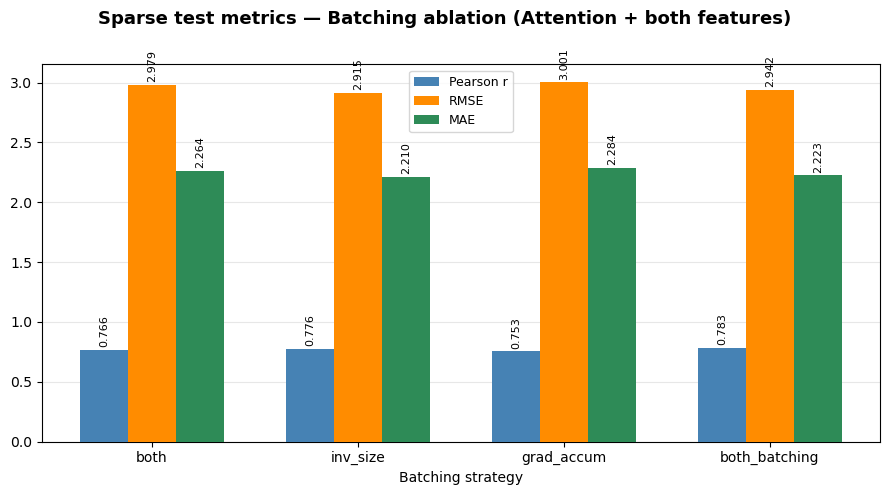

In [5]:
plot_batching_bars(df_bat, "Sparse test metrics — Batching ablation (Attention + both features)")

## 3. Training Noise Analysis

Do these changes actually reduce noise in training and loss thrashing?

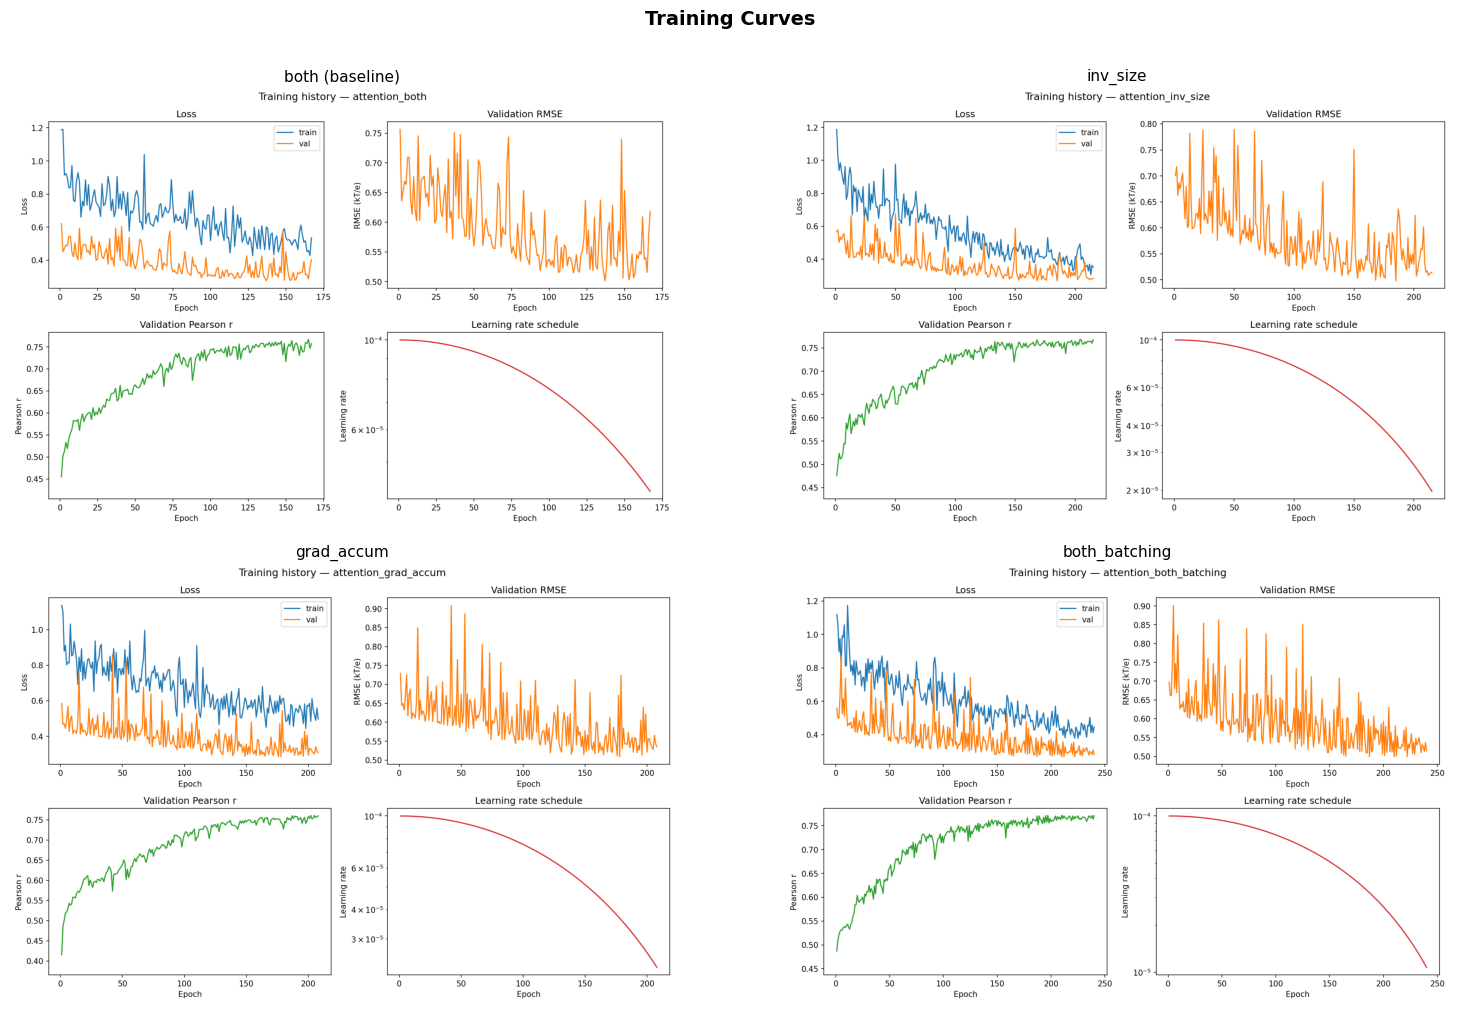

In [6]:
show_png_grid(BATCHING_RUNS, "training_curves.png", "Training Curves")

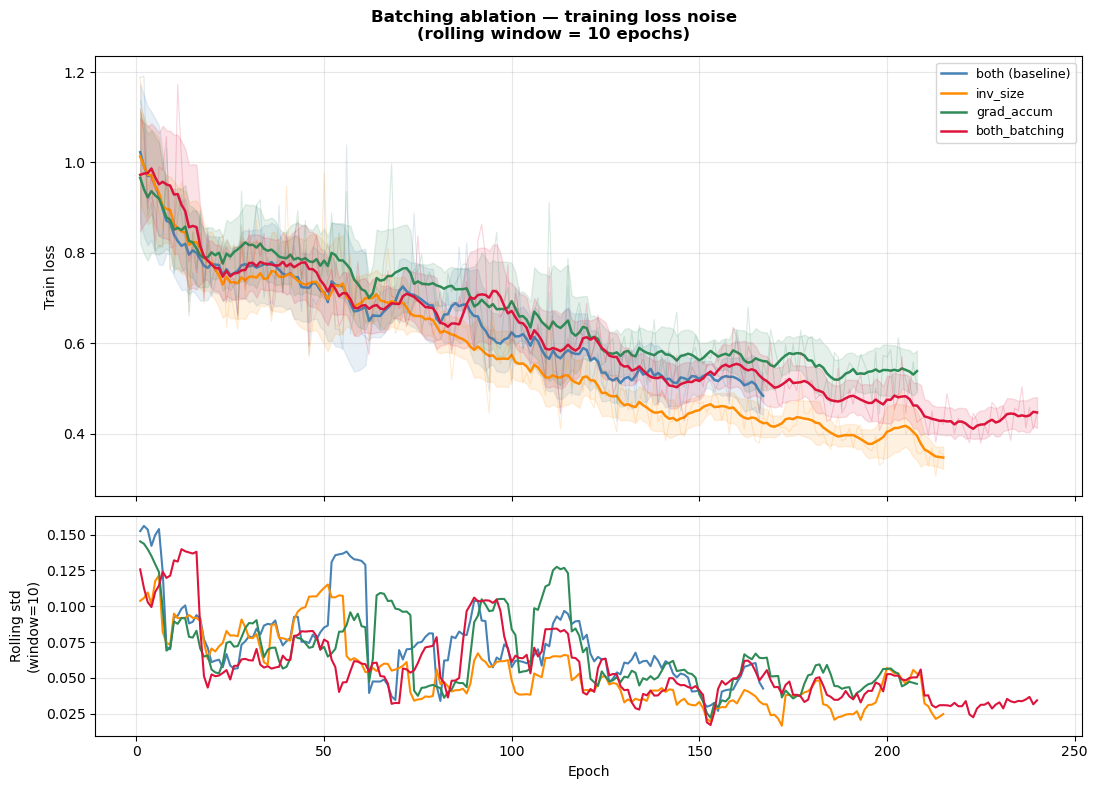


Strategy               Epochs  Final train loss   Mean σ (last 20%)
--------------------------------------------------------------------
both (baseline)           167            0.5356              0.0492
inv_size                  215            0.3508              0.0368
grad_accum                208            0.4973              0.0481
both_batching             240            0.4459              0.0372


In [7]:
ROLL_WINDOW = 10   # epochs for rolling mean / std

colors = ["steelblue", "darkorange", "seagreen", "crimson"]

curves = []
for run, color in zip(BATCHING_RUNS, colors):
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        print(f"  metrics.csv not found for {run['label']} — skipping")
        continue
    df_c = pd.read_csv(csv_path)
    df_c["roll_mean"] = df_c["train_loss"].rolling(ROLL_WINDOW, min_periods=1, center=True).mean()
    df_c["roll_std"]  = df_c["train_loss"].rolling(ROLL_WINDOW, min_periods=1, center=True).std().fillna(0)
    curves.append((run["label"], df_c, color))

if not curves:
    print("No metrics.csv files found — run the sweep first.")
else:
    fig, (ax_loss, ax_std) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                                           gridspec_kw={"height_ratios": [3, 1.5]})
    fig.suptitle(f"Batching ablation — training loss noise\n(rolling window = {ROLL_WINDOW} epochs)",
                 fontsize=12, fontweight="bold")

    for label, df_c, color in curves:
        epochs = df_c["epoch"]
        ax_loss.plot(epochs, df_c["train_loss"], color=color, alpha=0.18, linewidth=0.8)
        ax_loss.plot(epochs, df_c["roll_mean"],  color=color, linewidth=1.8, label=label)
        ax_loss.fill_between(epochs,
                             df_c["roll_mean"] - df_c["roll_std"],
                             df_c["roll_mean"] + df_c["roll_std"],
                             color=color, alpha=0.12)
        ax_std.plot(epochs, df_c["roll_std"], color=color, linewidth=1.5, label=label)

    ax_loss.set_ylabel("Train loss")
    ax_loss.legend(fontsize=9, loc="upper right")
    ax_loss.grid(alpha=0.3)
    ax_std.set_ylabel(f"Rolling std\n(window={ROLL_WINDOW})")
    ax_std.set_xlabel("Epoch")
    ax_std.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Strategy':<20}  {'Epochs':>7}  {'Final train loss':>16}  {'Mean σ (last 20%)':>18}")
    print("-" * 68)
    for label, df_c, _ in curves:
        n        = len(df_c)
        tail     = df_c.iloc[int(n * 0.8):]
        mean_std = tail["roll_std"].mean()
        final    = df_c["train_loss"].iloc[-1]
        print(f"{label:<20}  {n:>7}  {final:>16.4f}  {mean_std:>18.4f}")

## 4. Error Distributions

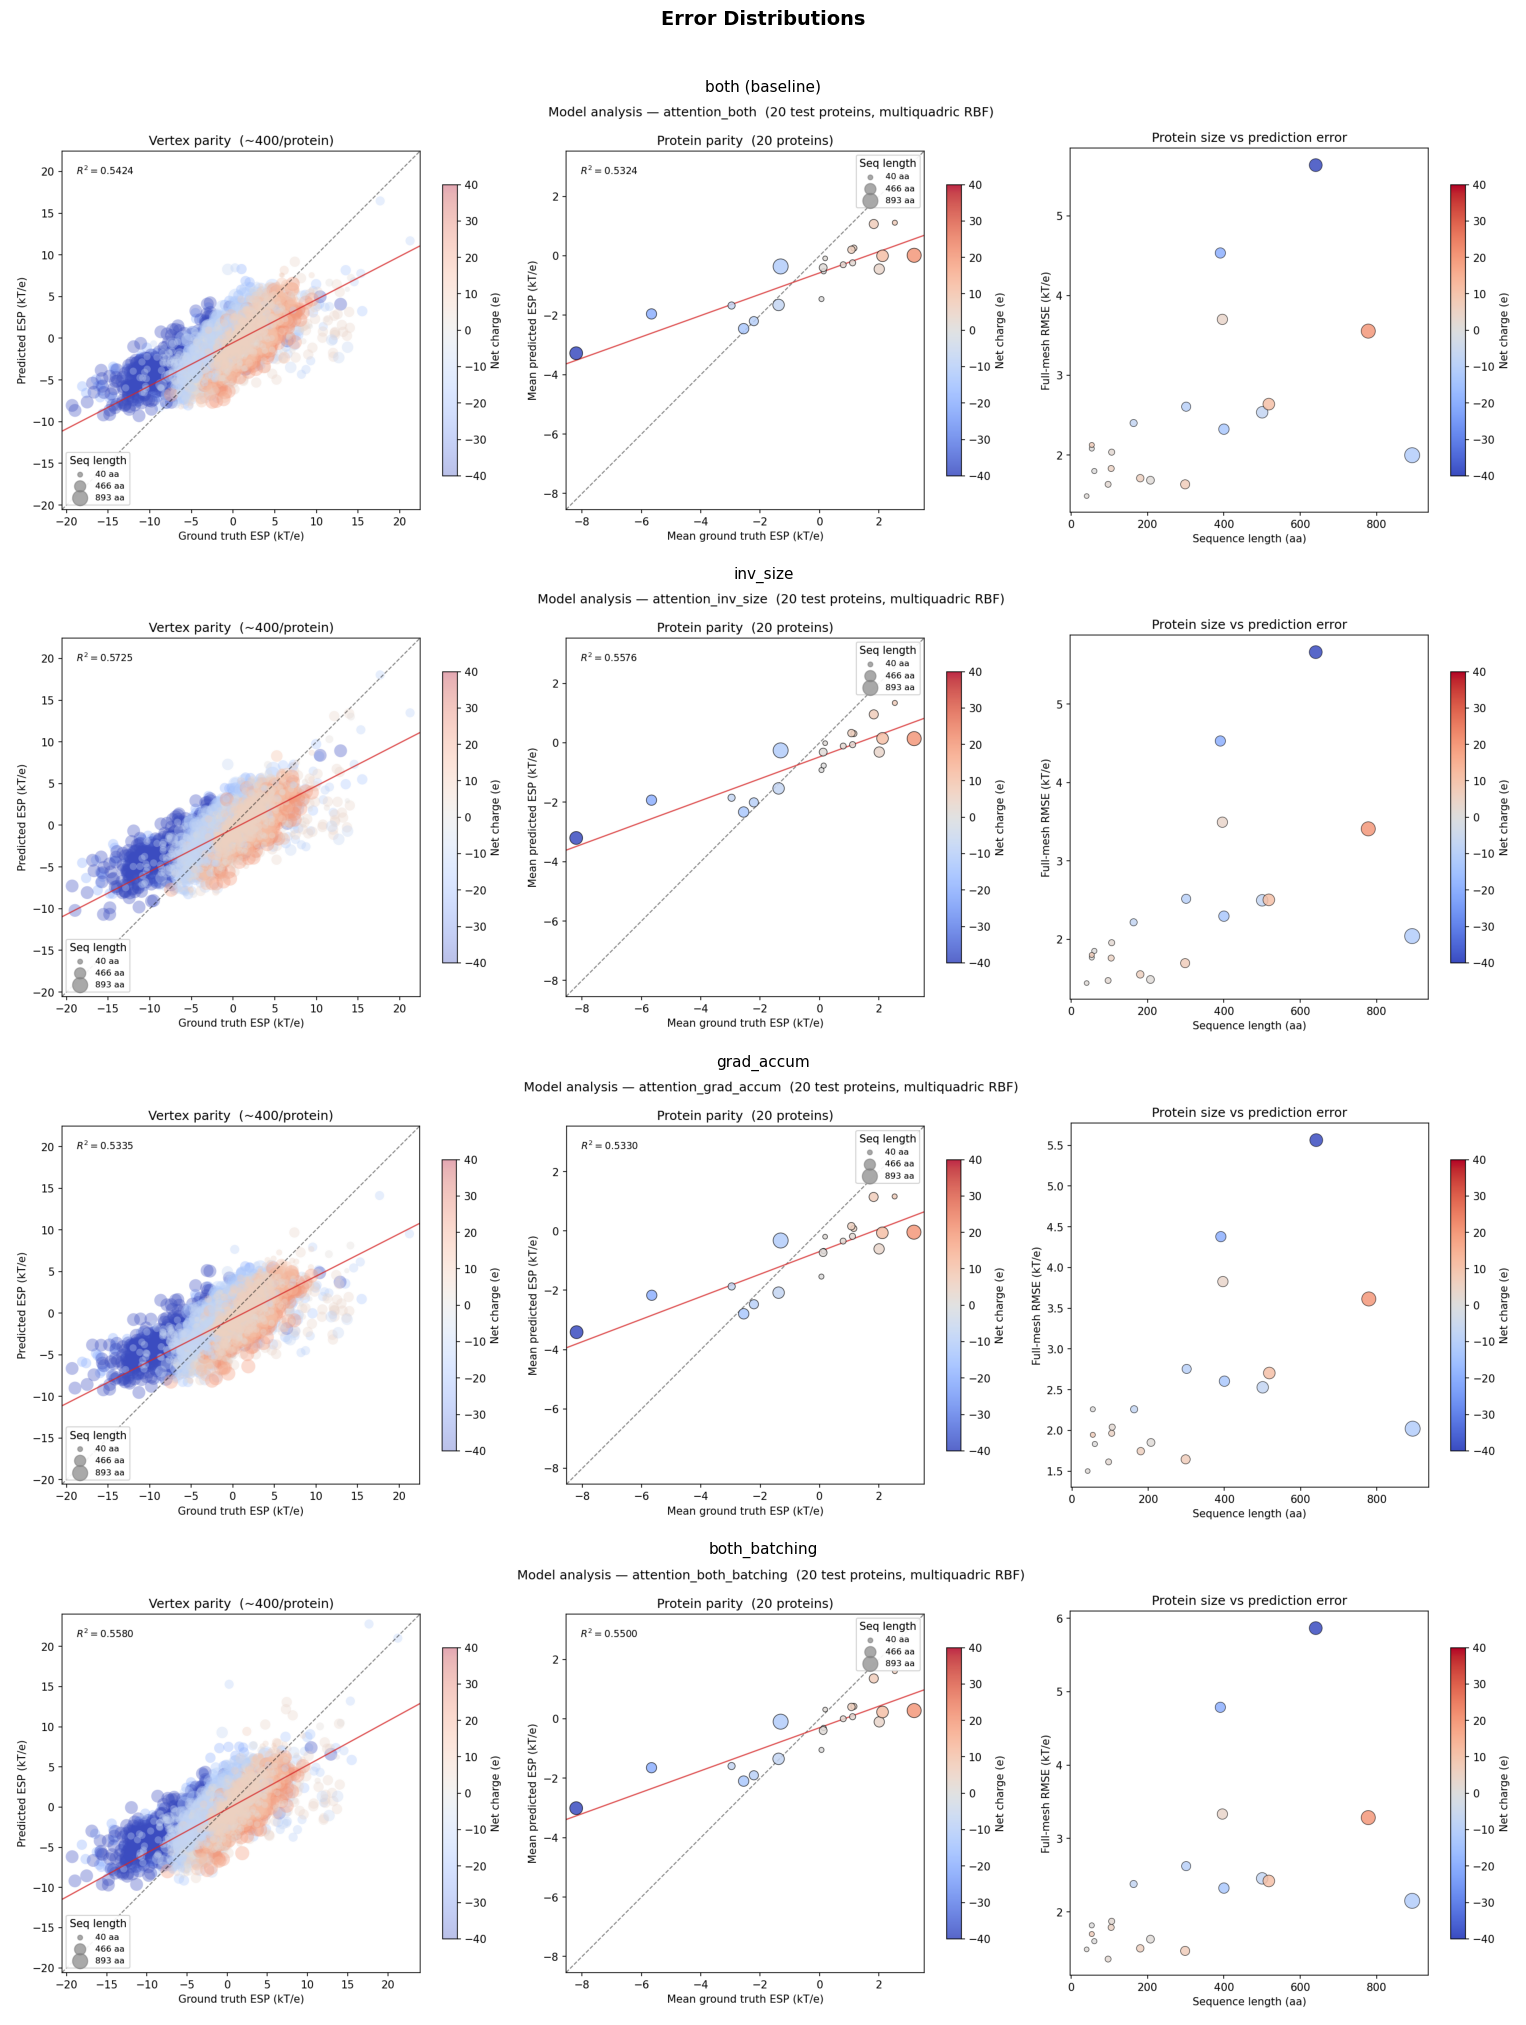

In [8]:
show_png_grid(BATCHING_RUNS, "error_distributions.png", "Error Distributions", ncols=1)